In [1]:
import pandas as pd


In [2]:
import numpy as np


In [3]:
import matplotlib.pyplot as plt


In [3]:
import matplotlib.pyplot as plt


In [5]:
import seaborn as sns


In [6]:
%matplotlib inline
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

In [7]:
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer

In [9]:
df= pd.read_csv(r"C:\Users\LENOVO\Desktop\MLproject\data\raw\retail_customers_COMPLETE_CATEGORICAL.csv")

In [11]:
print("=== APERÇU DES DONNÉES ===")
print(f"Shape: {df.shape}")
print(f"\nColonnes: {df.columns.tolist()}")
print(f"\nTypes de données:")
print(df.dtypes.value_counts())


=== APERÇU DES DONNÉES ===
Shape: (4372, 52)

Colonnes: ['CustomerID', 'Recency', 'Frequency', 'MonetaryTotal', 'MonetaryAvg', 'MonetaryStd', 'MonetaryMin', 'MonetaryMax', 'TotalQuantity', 'AvgQuantityPerTransaction', 'MinQuantity', 'MaxQuantity', 'CustomerTenureDays', 'FirstPurchaseDaysAgo', 'PreferredDayOfWeek', 'PreferredHour', 'PreferredMonth', 'WeekendPurchaseRatio', 'AvgDaysBetweenPurchases', 'UniqueProducts', 'UniqueDescriptions', 'AvgProductsPerTransaction', 'UniqueCountries', 'NegativeQuantityCount', 'ZeroPriceCount', 'CancelledTransactions', 'ReturnRatio', 'TotalTransactions', 'UniqueInvoices', 'AvgLinesPerInvoice', 'Age', 'RegistrationDate', 'NewsletterSubscribed', 'LastLoginIP', 'SupportTicketsCount', 'SatisfactionScore', 'RFMSegment', 'AgeCategory', 'SpendingCategory', 'CustomerType', 'FavoriteSeason', 'PreferredTimeOfDay', 'Region', 'LoyaltyLevel', 'ChurnRiskCategory', 'WeekendPreference', 'BasketSizeCategory', 'ProductDiversity', 'Gender', 'AccountStatus', 'Country', 'Ch

In [12]:
print("=== PREMIÈRES LIGNES ===")
df.head()


=== PREMIÈRES LIGNES ===


,CustomerID,Recency,Frequency,MonetaryTotal,MonetaryAvg,MonetaryStd,MonetaryMin,MonetaryMax,TotalQuantity,AvgQuantityPerTransaction,MinQuantity,MaxQuantity,CustomerTenureDays,FirstPurchaseDaysAgo,PreferredDayOfWeek,PreferredHour,PreferredMonth,WeekendPurchaseRatio,AvgDaysBetweenPurchases,UniqueProducts,UniqueDescriptions,AvgProductsPerTransaction,UniqueCountries,NegativeQuantityCount,ZeroPriceCount,CancelledTransactions,ReturnRatio,TotalTransactions,UniqueInvoices,AvgLinesPerInvoice,Age,RegistrationDate,NewsletterSubscribed,LastLoginIP,SupportTicketsCount,SatisfactionScore,RFMSegment,AgeCategory,SpendingCategory,CustomerType,FavoriteSeason,PreferredTimeOfDay,Region,LoyaltyLevel,ChurnRiskCategory,WeekendPreference,BasketSizeCategory,ProductDiversity,Gender,AccountStatus,Country,Churn
0,17850,302,35,5288.63,16.950737,13.603662,-30.60,107.25,1693,5.426282,-12,12,71,374,3,9,12,0.000000,0.221865,24,25,0.685714,1,15,0,15,0.048077,312,35,8.914286,NaN,17/07/10,Yes,59.252.219.201,1.0,4.0,Fidèles,Inconnu,VIP,Perdu,Hiver,Matin,UK,Jeune,Critique,Inconnu,Moyen,Explorateur,Unknown,Active,United Kingdom,1
1,13047,32,18,3079.10,15.709694,11.684769,-15.00,68.00,1355,6.913265,-3,32,342,374,2,13,10,0.168367,1.717949,106,106,5.888889,1,24,0,24,0.122449,196,18,10.888889,NaN,2010-10-04,Yes,77.255.247.14,3.0,4.0,Champions,Inconnu,VIP,Régulier,Automne,Midi,UK,Établi,Moyen,Semaine,Moyen,Explorateur,M,Active,United Kingdom,0
2,12583,3,18,7187.34,28.634821,23.150132,-60.84,132.80,5009,19.956175,-36,360,370,374,4,12,11,0.055777,1.456000,115,117,6.388889,1,4,0,4,0.015936,251,18,13.944444,46.0,12/09/2009,Yes,51.139.78.80,2.0,5.0,Champions,45-54,VIP,Hyperactif,Automne,Midi,Europe continentale,Ancien,Faible,Semaine,Grand,Explorateur,Unknown,Active,France,0
3,13748,96,5,948.25,33.866071,42.953119,9.36,204.00,439,15.678571,1,80,278,374,0,9,9,0.000000,10.259259,24,24,4.800000,1,0,0,0,0.000000,28,5,5.600000,32.0,28/01/10,Yes,10.212.80.124,2.0,2.0,Potentiels,25-34,High,Nouveau,Automne,Matin,UK,Établi,Critique,Inconnu,Grand,Explorateur,Unknown,Active,United Kingdom,1
4,15100,330,6,635.10,105.850000,215.986263,-131.40,350.40,58,9.666667,-12,32,43,374,2,9,12,0.000000,8.200000,1,1,0.166667,1,3,0,3,0.500000,6,6,1.000000,NaN,2009-12-10,Yes,186.34.121.80,2.0,1.0,Potentiels,Inconnu,High,Perdu,Hiver,Matin,UK,Jeune,Critique,Inconnu,Moyen,Spécialisé,M,Active,United Kingdom,1


In [13]:
print("=== INFORMATIONS GÉNÉRALES ===")
df.info()

=== INFORMATIONS GÉNÉRALES ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4372 entries, 0 to 4371
Data columns (total 52 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   CustomerID                 4372 non-null   int64  
 1   Recency                    4372 non-null   int64  
 2   Frequency                  4372 non-null   int64  
 3   MonetaryTotal              4372 non-null   float64
 4   MonetaryAvg                4372 non-null   float64
 5   MonetaryStd                4372 non-null   float64
 6   MonetaryMin                4372 non-null   float64
 7   MonetaryMax                4372 non-null   float64
 8   TotalQuantity              4372 non-null   int64  
 9   AvgQuantityPerTransaction  4372 non-null   float64
 10  MinQuantity                4372 non-null   int64  
 11  MaxQuantity                4372 non-null   int64  
 12  CustomerTenureDays         4372 non-null   int64  
 13  FirstPurchaseDays

In [14]:
print("=== STATISTIQUES DESCRIPTIVES ===")
df.describe(include='all').T

=== STATISTIQUES DESCRIPTIVES ===


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
CustomerID,4372.0,NaN,NaN,NaN,15299.677722,1722.390705,12346.0,13812.75,15300.5,16778.25,18287.0
Recency,4372.0,NaN,NaN,NaN,92.047118,100.765435,1.0,17.0,50.0,143.0,374.0
Frequency,4372.0,NaN,NaN,NaN,5.07548,9.338754,1.0,1.0,3.0,5.0,248.0
MonetaryTotal,4372.0,NaN,NaN,NaN,1898.459701,8219.345141,-4287.63,293.3625,648.075,1611.725,279489.02
MonetaryAvg,4372.0,NaN,NaN,NaN,28.839013,127.323926,-4287.63,10.98596,16.918616,23.542941,3861.0
MonetaryStd,4372.0,NaN,NaN,NaN,88.672383,2689.001161,0.0,6.226414,10.34978,20.629858,137554.852393
MonetaryMin,4372.0,NaN,NaN,NaN,-86.425754,2876.398935,-168469.6,-11.5,0.79,6.96,3861.0
MonetaryMax,4372.0,NaN,NaN,NaN,185.179522,2881.283699,-4287.63,31.8,52.02,102.0,168469.6
TotalQuantity,4372.0,NaN,NaN,NaN,1122.344007,4672.79072,-303.0,153.0,365.0,962.25,196719.0
AvgQuantityPerTransaction,4372.0,NaN,NaN,NaN,22.389288,213.257466,-144.0,5.475745,9.494392,14.008333,12540.0


In [19]:
# Calcul du pourcentage de valeurs manquantes
missing_data = pd.DataFrame({
    'Colonne': df.columns,
    'Type': df.dtypes.values,
    'Valeurs_Manquantes': df.isnull().sum().values,
    'Pourcentage': (df.isnull().sum() / len(df) * 100).values
})
missing_data = missing_data.sort_values('Pourcentage', ascending=False)

print("=== ANALYSE DES VALEURS MANQUANTES ===")
missing_data[missing_data['Valeurs_Manquantes'] > 0]


=== ANALYSE DES VALEURS MANQUANTES ===


,Colonne,Type,Valeurs_Manquantes,Pourcentage
30,Age,float64,1311,29.986276
18,AvgDaysBetweenPurchases,float64,79,1.806953


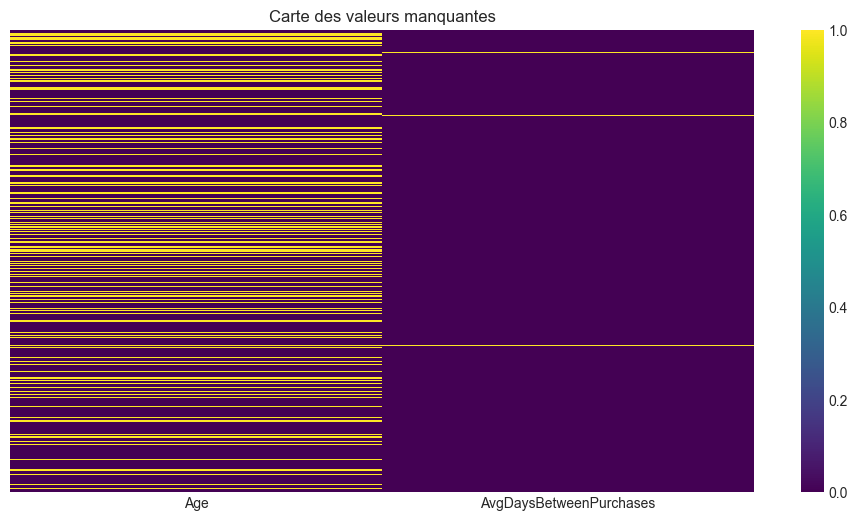

In [20]:
# Visualisation des valeurs manquantes
plt.figure(figsize=(12, 6))
missing_cols = missing_data[missing_data['Pourcentage'] > 0]['Colonne'].tolist()
if missing_cols:
    sns.heatmap(df[missing_cols].isnull(), yticklabels=False, cbar=True, cmap='viridis')
    plt.title('Carte des valeurs manquantes')
    plt.show()
else:
    print("Aucune valeur manquante détectée")

In [29]:
# Identifier les colonnes numériques
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print(f"Colonnes numériques ({len(numeric_cols)}): {numeric_cols}")



Colonnes numériques (34): ['CustomerID', 'Recency', 'Frequency', 'MonetaryTotal', 'MonetaryAvg', 'MonetaryStd', 'MonetaryMin', 'MonetaryMax', 'TotalQuantity', 'AvgQuantityPerTransaction', 'MinQuantity', 'MaxQuantity', 'CustomerTenureDays', 'FirstPurchaseDaysAgo', 'PreferredDayOfWeek', 'PreferredHour', 'PreferredMonth', 'WeekendPurchaseRatio', 'AvgDaysBetweenPurchases', 'UniqueProducts', 'UniqueDescriptions', 'AvgProductsPerTransaction', 'UniqueCountries', 'NegativeQuantityCount', 'ZeroPriceCount', 'CancelledTransactions', 'ReturnRatio', 'TotalTransactions', 'UniqueInvoices', 'AvgLinesPerInvoice', 'Age', 'SupportTicketsCount', 'SatisfactionScore', 'Churn']


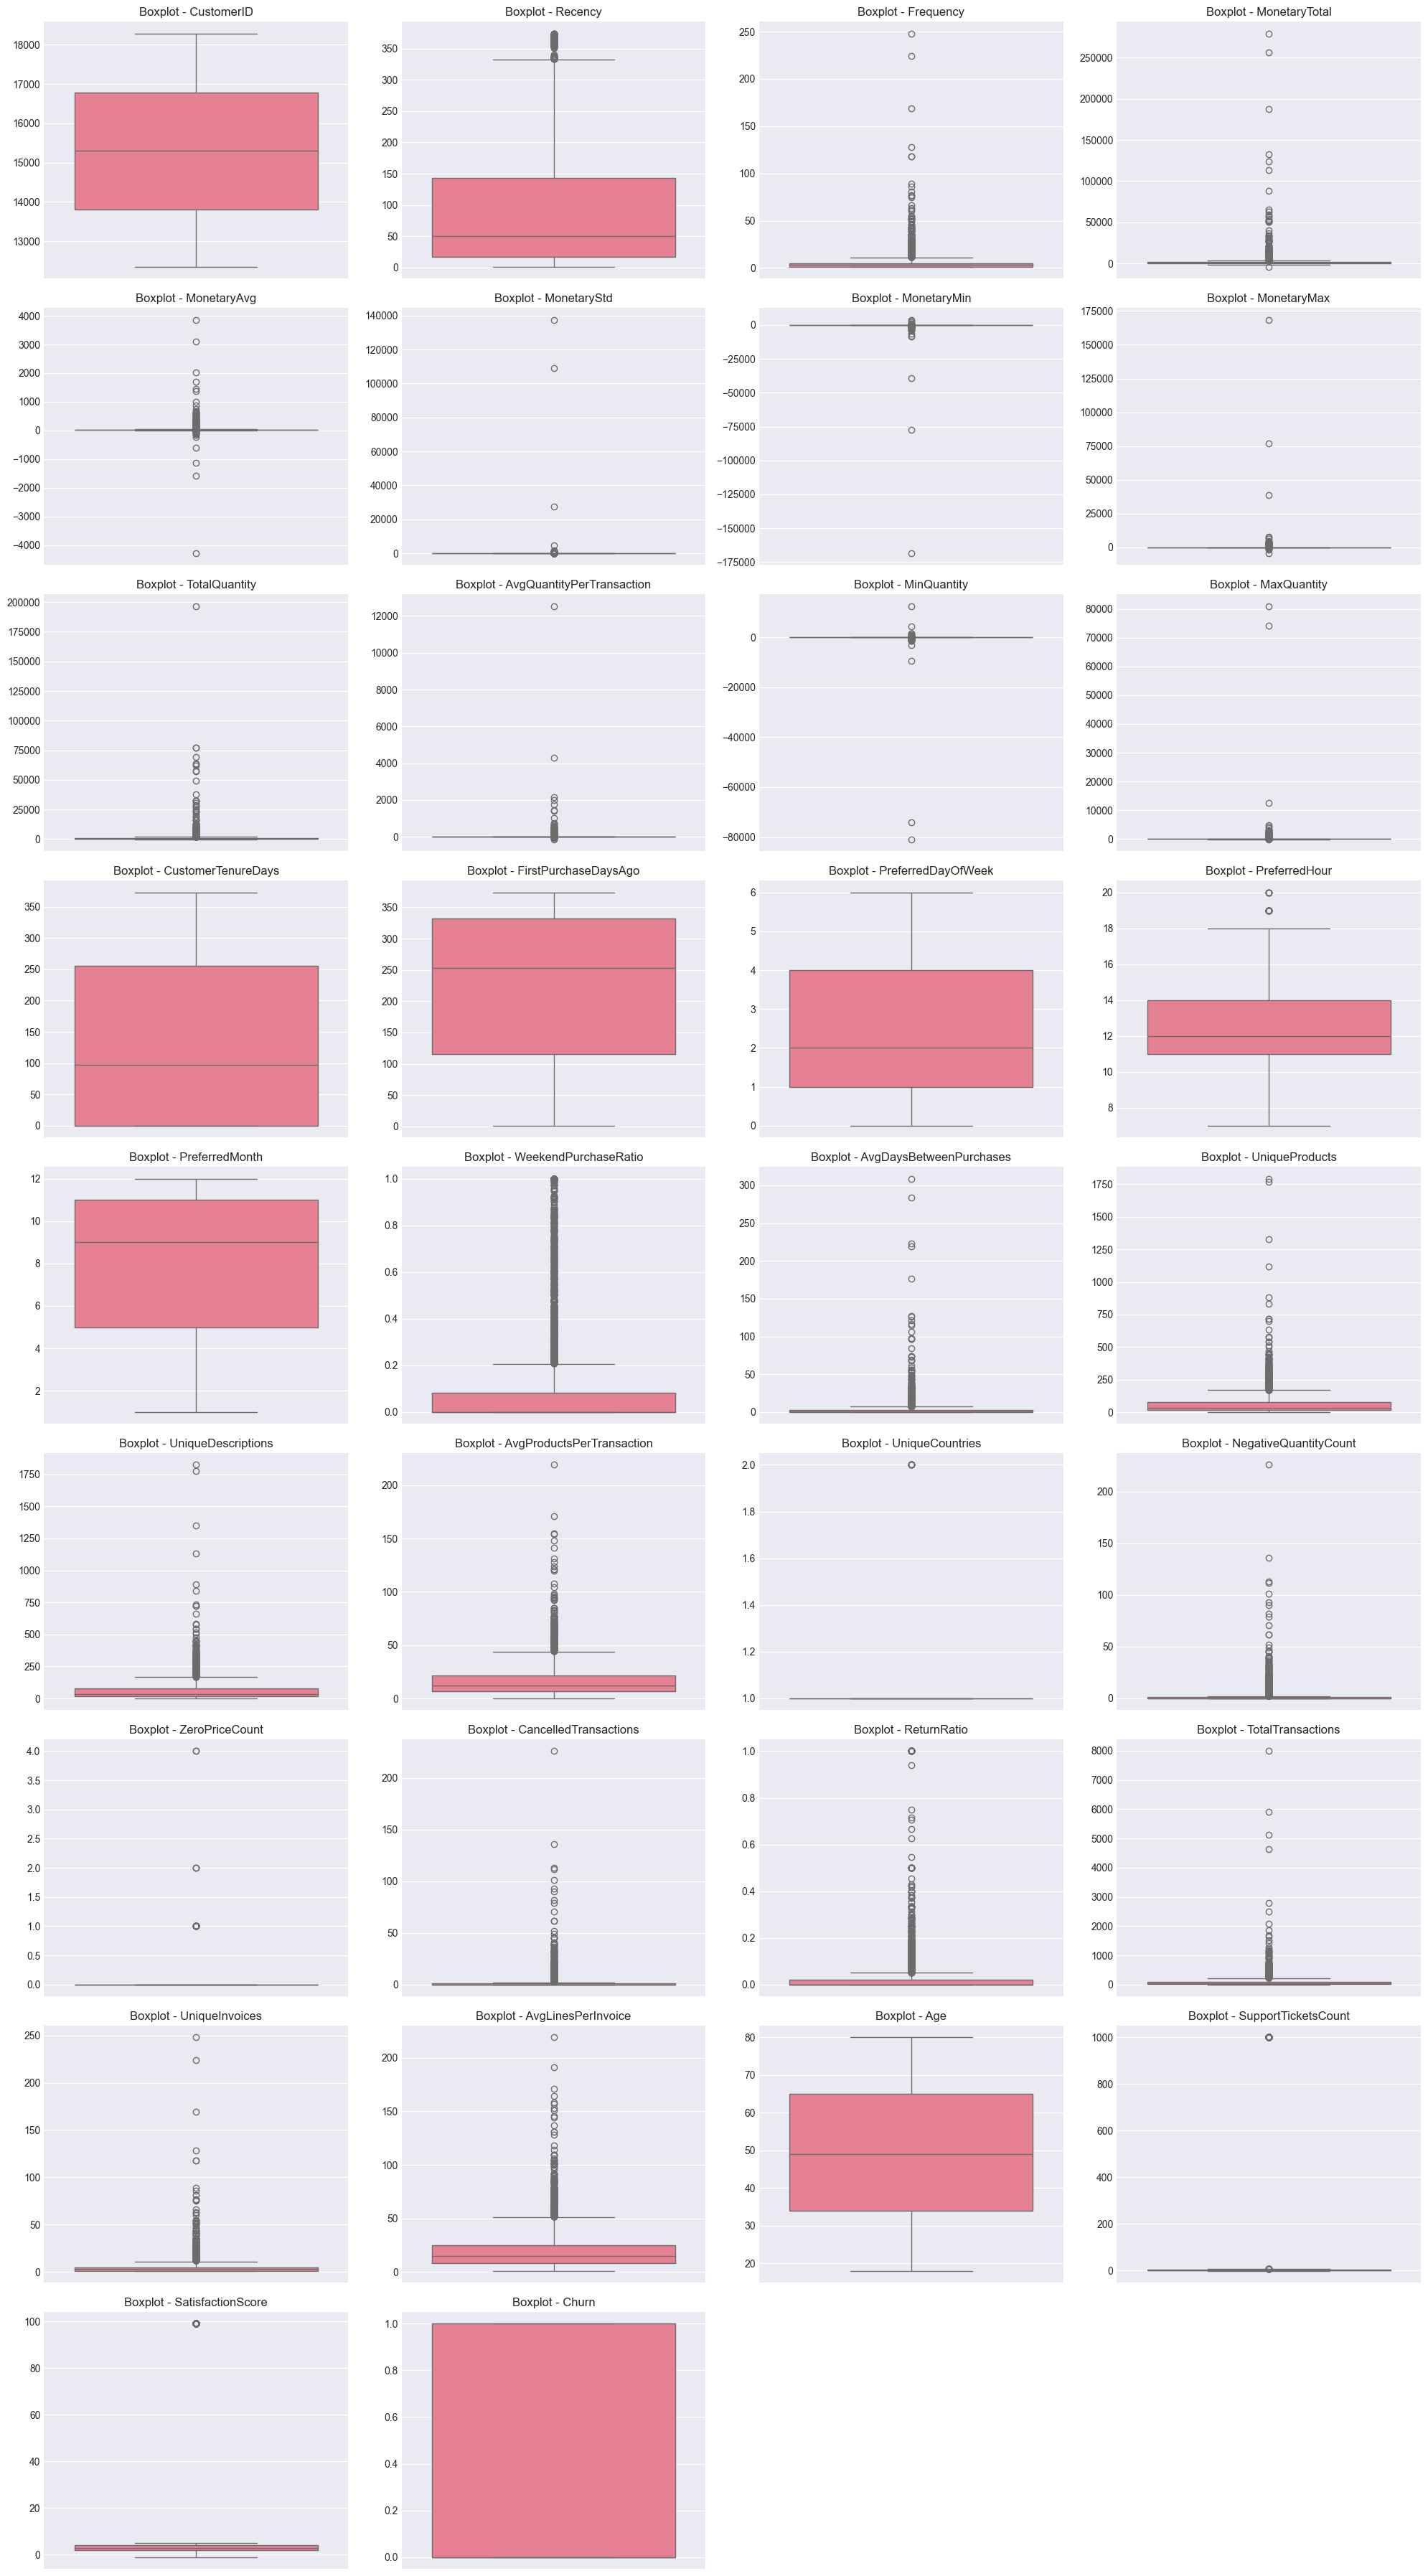

In [30]:


# Boxplots pour détecter les outliers
n_cols = 4
n_rows = (len(numeric_cols) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.boxplot(data=df, y=col, ax=axes[i])
    axes[i].set_title(f'Boxplot - {col}')
    axes[i].set_ylabel('')

# Supprimer les sous-graphiques vides
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [31]:
# Analyse statistique des outliers (méthode IQR)
outliers_summary = []

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    
    outliers_summary.append({
        'Colonne': col,
        'Outliers': len(outliers),
        'Pourcentage': (len(outliers) / len(df) * 100),
        'Min': df[col].min(),
        'Max': df[col].max(),
        'Borne_inf': lower_bound,
        'Borne_sup': upper_bound
    })

outliers_df = pd.DataFrame(outliers_summary)
outliers_df = outliers_df.sort_values('Outliers', ascending=False)
print("=== ANALYSE DES OUTLIERS (Méthode IQR) ===")
outliers_df[outliers_df['Outliers'] > 0]

=== ANALYSE DES OUTLIERS (Méthode IQR) ===


,Colonne,Outliers,Pourcentage,Min,Max,Borne_inf,Borne_sup
17,WeekendPurchaseRatio,833,19.053065,0.000000,1.000000,-0.125000,0.208333
25,CancelledTransactions,783,17.909424,0.000000,226.000000,-1.500000,2.500000
23,NegativeQuantityCount,783,17.909424,0.000000,226.000000,-1.500000,2.500000
10,MinQuantity,771,17.634950,-80995.000000,12540.000000,-8.000000,8.000000
26,ReturnRatio,623,14.249771,0.000000,1.000000,-0.031514,0.052523
6,MonetaryMin,519,11.870997,-168469.600000,3861.000000,-39.190000,34.650000
4,MonetaryAvg,505,11.550778,-4287.630000,3861.000000,-7.849512,42.378412
7,MonetaryMax,501,11.459286,-4287.630000,168469.600000,-73.500000,207.300000
5,MonetaryStd,482,11.024703,0.000000,137554.852393,-15.378752,42.235024
3,MonetaryTotal,423,9.675206,-4287.630000,279489.020000,-1684.181250,3589.268750


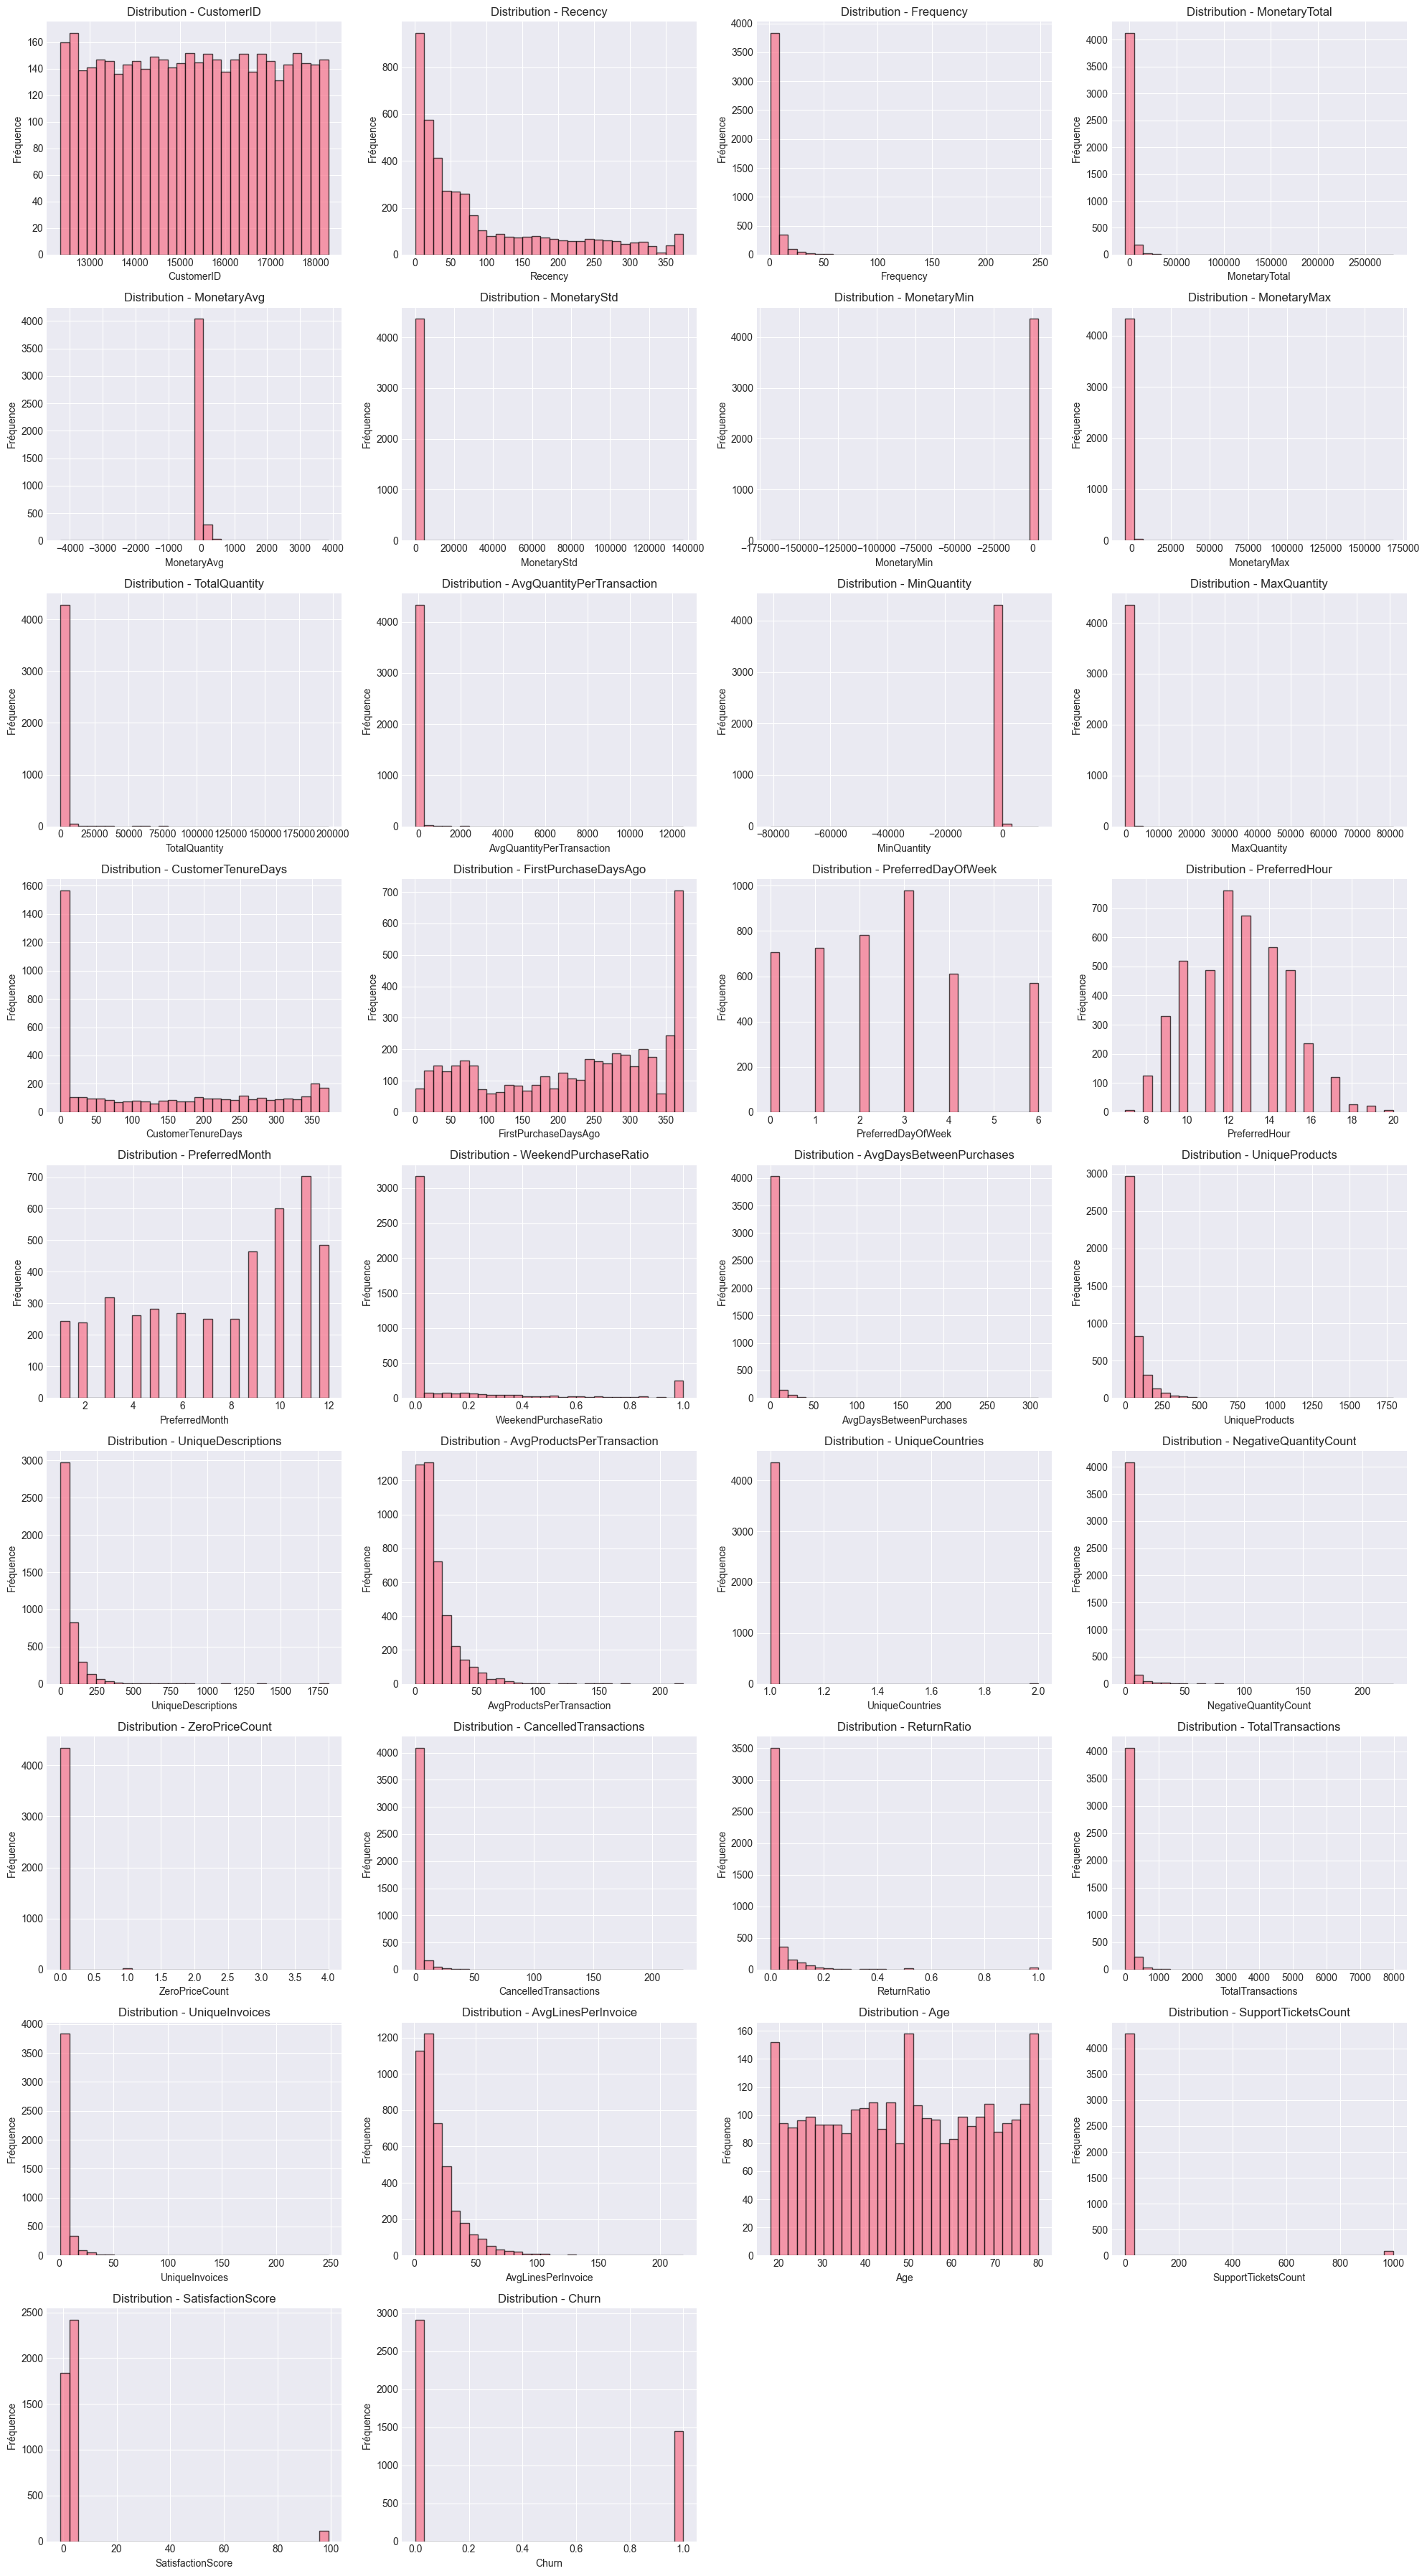

In [32]:
# Histogrammes pour les distributions
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    axes[i].hist(df[col].dropna(), bins=30, edgecolor='black', alpha=0.7)
    axes[i].set_title(f'Distribution - {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Fréquence')

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


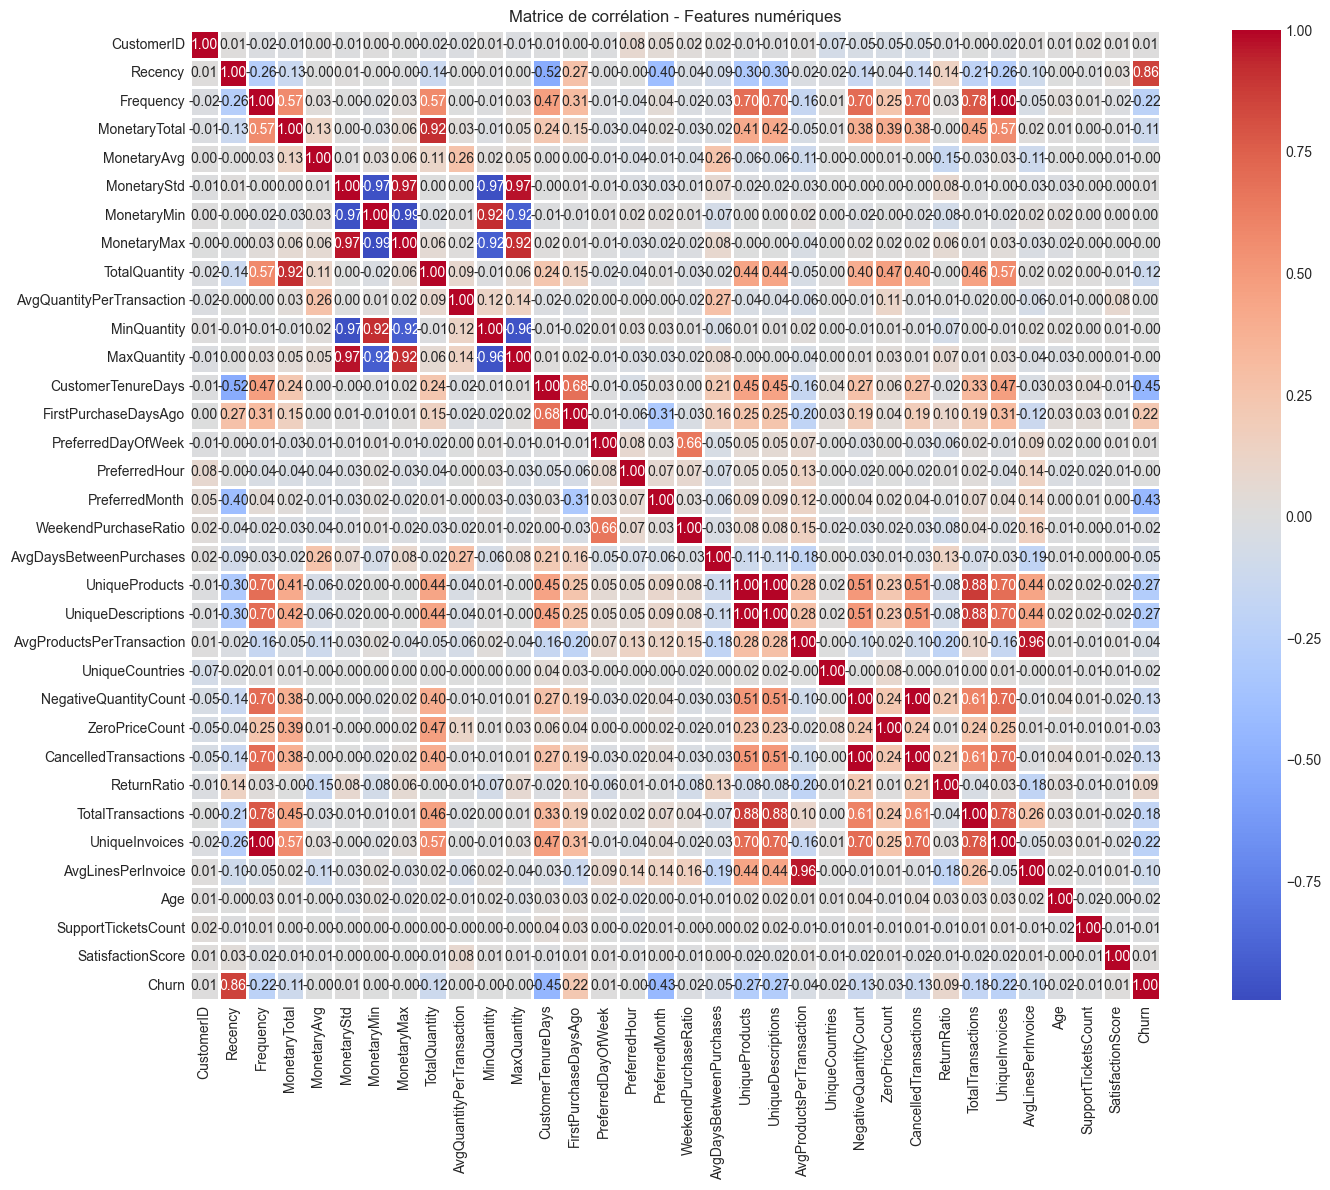

In [33]:
# Matrice de corrélation
corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(16, 12))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, square=True, linewidths=1)
plt.title('Matrice de corrélation - Features numériques')
plt.tight_layout()
plt.show()

In [34]:
# Identifier les paires fortement corrélées
threshold = 0.8
high_corr = []

for i in range(len(corr_matrix.columns)):
    for j in range(i):
        if abs(corr_matrix.iloc[i, j]) > threshold:
            high_corr.append({
                'Feature_1': corr_matrix.columns[i],
                'Feature_2': corr_matrix.columns[j],
                'Corrélation': corr_matrix.iloc[i, j]
            })

high_corr_df = pd.DataFrame(high_corr).sort_values('Corrélation', ascending=False)
print(f"=== PAIRES FORTEMENT CORRÉLÉES (|r| > {threshold}) ===")
high_corr_df

=== PAIRES FORTEMENT CORRÉLÉES (|r| > 0.8) ===


,Feature_1,Feature_2,Corrélation
12,CancelledTransactions,NegativeQuantityCount,1.000000
15,UniqueInvoices,Frequency,1.000000
11,UniqueDescriptions,UniqueProducts,0.999930
7,MaxQuantity,MonetaryStd,0.972585
1,MonetaryMax,MonetaryStd,0.966135
16,AvgLinesPerInvoice,AvgProductsPerTransaction,0.963210
3,TotalQuantity,MonetaryTotal,0.921649
9,MaxQuantity,MonetaryMax,0.920975
5,MinQuantity,MonetaryMin,0.919252
14,TotalTransactions,UniqueDescriptions,0.879734


In [38]:
# ## 8. Analyse des features catégorielles

# %%
# Identifier les colonnes catégorielles
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
print(f"Colonnes catégorielles ({len(categorical_cols)}): {categorical_cols}")

Colonnes catégorielles (18): ['RegistrationDate', 'NewsletterSubscribed', 'LastLoginIP', 'RFMSegment', 'AgeCategory', 'SpendingCategory', 'CustomerType', 'FavoriteSeason', 'PreferredTimeOfDay', 'Region', 'LoyaltyLevel', 'ChurnRiskCategory', 'WeekendPreference', 'BasketSizeCategory', 'ProductDiversity', 'Gender', 'AccountStatus', 'Country']


In [39]:
# Analyse des valeurs uniques par colonne catégorielle
if categorical_cols:
    cat_summary = []
    for col in categorical_cols:
        cat_summary.append({
            'Colonne': col,
            'Valeurs_uniques': df[col].nunique(),
            'Valeurs': df[col].unique()[:10].tolist(),  # 10 premières valeurs
            'Modale': df[col].mode().iloc[0] if not df[col].mode().empty else None,
            'Fréquence_modale': df[col].value_counts().iloc[0] if not df[col].value_counts().empty else 0
        })
    
    cat_summary_df = pd.DataFrame(cat_summary)
    print("=== ANALYSE DES COLONNES CATÉGORIELLES ===")
    display(cat_summary_df)

=== ANALYSE DES COLONNES CATÉGORIELLES ===


,Colonne,Valeurs_uniques,Valeurs,Modale,Fréquence_modale
0,RegistrationDate,1700,"[17/07/10, 2010-10-04, 12/09/2009, 28/01/10, 2...",12/10/2010,11
1,NewsletterSubscribed,1,[Yes],Yes,4372
2,LastLoginIP,4372,"[59.252.219.201, 77.255.247.14, 51.139.78.80, ...",1.107.28.50,1
3,RFMSegment,4,"[Fidèles, Champions, Potentiels, Dormants]",Potentiels,1589
4,AgeCategory,7,"[Inconnu, 45-54, 25-34, 65+, 35-44, 18-24, 55-64]",Inconnu,1311
5,SpendingCategory,4,"[VIP, High, Medium, Low]",High,1664
6,CustomerType,5,"[Perdu, Régulier, Hyperactif, Nouveau, Occasio...",Occasionnel,1198
7,FavoriteSeason,4,"[Hiver, Automne, Été, Printemps]",Automne,1768
8,PreferredTimeOfDay,4,"[Matin, Midi, Après-midi, Soir]",Matin,1471
9,Region,13,"[UK, Europe continentale, Océanie, Europe du N...",UK,3959


In [44]:
# Vérifier si 'Churn' existe (feature 34)
if 'Churn' in df.columns:
    print("=== ANALYSE DE LA VARIABLE CIBLE (CHURN) ===")
    churn_counts = df['Churn'].value_counts()
    churn_percentages = df['Churn'].value_counts(normalize=True) * 100
    
    churn_df = pd.DataFrame({
        'Classe': churn_counts.index,
        'Effectif': churn_counts.values,
        'Pourcentage': churn_percentages.values
    })
    print(churn_df)
    

=== ANALYSE DE LA VARIABLE CIBLE (CHURN) ===
   Classe  Effectif  Pourcentage
0       0      2918    66.742909
1       1      1454    33.257091


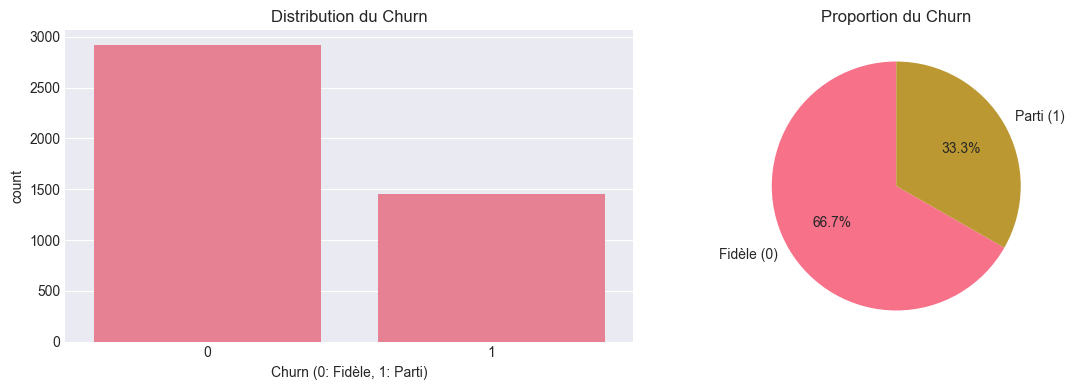

In [50]:
    # Visualisation
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    
    # Countplot
    sns.countplot(data=df, x='Churn', ax=axes[0])
    axes[0].set_title('Distribution du Churn')
    axes[0].set_xlabel('Churn (0: Fidèle, 1: Parti)')
    
    # Pie chart
    axes[1].pie(churn_counts.values, labels=['Fidèle (0)', 'Parti (1)'], 
                autopct='%1.1f%%', startangle=90)
    axes[1].set_title('Proportion du Churn')
    
    plt.tight_layout()
    plt.show()
 
   


In [59]:
 
    # Analyser le déséquilibre potentiel
    min_class_pct = churn_percentages.min()
    if min_class_pct < 20:
        print(f"\n⚠️ ATTENTION: Déséquilibre des classes détecté!")
        print(f"La classe minoritaire ne représente que {min_class_pct:.1f}% des données")
        print("→ Penser à utiliser stratify dans train_test_split")
        print("→ Envisager SMOTE ou class_weight pour la modélisation")
    else :print("class reasonably balanced")

class reasonably balanced


In [63]:

# Créer un résumé des problèmes de qualité
quality_issues = []

# 1. Valeurs manquantes
missing_issues = missing_data[missing_data['Pourcentage'] > 0]
for _, row in missing_issues.iterrows():
    quality_issues.append({
        'Type': 'Valeurs manquantes',
        'Feature': row['Colonne'],
        'Problème': f"{row['Pourcentage']:.1f}% de valeurs manquantes",
        'Action': 'À imputer'
    })

# 2. Outliers sévères (>5% outliers)
severe_outliers = outliers_df[outliers_df['Pourcentage'] > 5]
for _, row in severe_outliers.iterrows():
    quality_issues.append({
        'Type': 'Outliers sévères',
        'Feature': row['Colonne'],
        'Problème': f"{row['Pourcentage']:.1f}% de valeurs aberrantes",
        'Action': 'À traiter (capping/transformation)'
    })

# 3. Fortes corrélations (multicolinéarité)
for _, row in high_corr_df.iterrows():
    quality_issues.append({
        'Type': 'Multicolinéarité',
        'Feature': f"{row['Feature_1']} vs {row['Feature_2']}",
        'Problème': f"Corrélation de {row['Corrélation']:.2f}",
        'Action': 'À réduire (supprimer une feature ou ACP)'
    })

# 4. Colonnes constantes ou quasi-constantes
for col in numeric_cols:
    if df[col].nunique() == 1:
        quality_issues.append({
            'Type': 'Variance nulle',
            'Feature': col,
            'Problème': 'Colonne constante',
            'Action': 'À supprimer'
        })
    elif df[col].nunique() < 10 and len(df) > 1000:
        quality_issues.append({
            'Type': 'Faible variance',
            'Feature': col,
            'Problème': f"Seulement {df[col].nunique()} valeurs uniques",
            'Action': 'À vérifier si utile'
        })

quality_summary = pd.DataFrame(quality_issues)
print("=== SYNTHÈSE DES PROBLÈMES DE QUALITÉ IDENTIFIÉS ===")
if len(quality_summary) > 0:
    display(quality_summary)
else:
    print("✅ Aucun problème de qualité majeur détecté!")

=== SYNTHÈSE DES PROBLÈMES DE QUALITÉ IDENTIFIÉS ===


,Type,Feature,Problème,Action
0,Valeurs manquantes,Age,30.0% de valeurs manquantes,À imputer
1,Valeurs manquantes,AvgDaysBetweenPurchases,1.8% de valeurs manquantes,À imputer
2,Outliers sévères,WeekendPurchaseRatio,19.1% de valeurs aberrantes,À traiter (capping/transformation)
3,Outliers sévères,CancelledTransactions,17.9% de valeurs aberrantes,À traiter (capping/transformation)
4,Outliers sévères,NegativeQuantityCount,17.9% de valeurs aberrantes,À traiter (capping/transformation)
5,Outliers sévères,MinQuantity,17.6% de valeurs aberrantes,À traiter (capping/transformation)
6,Outliers sévères,ReturnRatio,14.2% de valeurs aberrantes,À traiter (capping/transformation)
7,Outliers sévères,MonetaryMin,11.9% de valeurs aberrantes,À traiter (capping/transformation)
8,Outliers sévères,MonetaryAvg,11.6% de valeurs aberrantes,À traiter (capping/transformation)
9,Outliers sévères,MonetaryMax,11.5% de valeurs aberrantes,À traiter (capping/transformation)


In [73]:
pip install openpyxl


   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   ---------------------------------------- 2/2 [openpyxl]

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [74]:
# Sauvegarder les statistiques dans un fichier pour référence
with pd.ExcelWriter(r"C:\Users\LENOVO\Desktop\MLproject\reports\exploration_report.xlsx") as writer:
    # Feuilles principales
    missing_data.to_excel(writer, sheet_name='Valeurs_manquantes', index=False)
    outliers_df.to_excel(writer, sheet_name='Outliers', index=False)
    high_corr_df.to_excel(writer, sheet_name='Correlations_elevees', index=False)
    
    # Statistiques générales
    df.describe(include='all').to_excel(writer, sheet_name='Statistiques')
    
    # Synthèse des problèmes
    if len(quality_issues) > 0:
        quality_summary.to_excel(writer, sheet_name='Problemes_qualite', index=False)
    
print("Rapport d'exploration sauvegardé")

Rapport d'exploration sauvegardé


In [78]:
# %%
# Sauvegarder une version propre des données (sans modifications pour l'instant)
# Cela servira de point de départ pour le preprocessing
df.to_csv(r"C:\Users\LENOVO\Desktop\MLproject\data\processed\df_clean_start.csv", index=False)
print("✅ Données sauvegardées dans 'data/processed/df_clean_start.csv'")

✅ Données sauvegardées dans 'data/processed/df_clean_start.csv'






=== PROCHAINES ÉTAPES ===
1. Traiter les valeurs manquantes (imputation)
2. Traiter les outliers (capping/transformation)
3. Encoder les variables catégorielles
4. Normaliser/standardiser les données
5. Feature engineering
6. Sauvegarder les données préparées

